In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#Simular por 100,000 jugadores
np.random.seed(42)
n_players = 100000
precio = np.random.choice(['Alto', 'Medio', 'Bajo'], size=n_players, p=[0.25, 0.50, 0.25])
criticas_positivas = np.random.choice(['Alta', 'Baja'], size=n_players, p=[0.6, 0.4])
amigos_juegan = np.random.choice(['Si', 'No'], size=n_players, p=[0.4, 0.6])
compra = np.zeros(n_players)

In [6]:
# Asignar compra basada en precio, críticas y amigos
for i in range(n_players):

    # PRECIO BAJO
    if precio[i] == 'Bajo' and criticas_positivas[i] == 'Alta' and amigos_juegan[i] == 'Si':
        compra[i] = np.random.choice([1, 0], p=[0.90, 0.10])
    elif precio[i] == 'Bajo' and criticas_positivas[i] == 'Alta' and amigos_juegan[i] == 'No':
        compra[i] = np.random.choice([1, 0], p=[0.75, 0.25])
    elif precio[i] == 'Bajo' and criticas_positivas[i] == 'Baja' and amigos_juegan[i] == 'Si':
        compra[i] = np.random.choice([1, 0], p=[0.70, 0.30])
    elif precio[i] == 'Bajo' and criticas_positivas[i] == 'Baja' and amigos_juegan[i] == 'No':
        compra[i] = np.random.choice([1, 0], p=[0.50, 0.50])

    # PRECIO MEDIO
    elif precio[i] == 'Medio' and criticas_positivas[i] == 'Alta' and amigos_juegan[i] == 'Si':
        compra[i] = np.random.choice([1, 0], p=[0.80, 0.20])
    elif precio[i] == 'Medio' and criticas_positivas[i] == 'Alta' and amigos_juegan[i] == 'No':
        compra[i] = np.random.choice([1, 0], p=[0.60, 0.40])
    elif precio[i] == 'Medio' and criticas_positivas[i] == 'Baja' and amigos_juegan[i] == 'Si':
        compra[i] = np.random.choice([1, 0], p=[0.55, 0.45])
    elif precio[i] == 'Medio' and criticas_positivas[i] == 'Baja' and amigos_juegan[i] == 'No':
        compra[i] = np.random.choice([1, 0], p=[0.35, 0.65])

    # PRECIO ALTO
    elif precio[i] == 'Alto' and criticas_positivas[i] == 'Alta' and amigos_juegan[i] == 'Si':
        compra[i] = np.random.choice([1, 0], p=[0.65, 0.35])
    elif precio[i] == 'Alto' and criticas_positivas[i] == 'Alta' and amigos_juegan[i] == 'No':
        compra[i] = np.random.choice([1, 0], p=[0.40, 0.60])
    elif precio[i] == 'Alto' and criticas_positivas[i] == 'Baja' and amigos_juegan[i] == 'Si':
        compra[i] = np.random.choice([1, 0], p=[0.30, 0.70])
    else:  # Alto, Baja, No
        compra[i] = np.random.choice([1, 0], p=[0.10, 0.90])



In [7]:
#Crear a DataFrame
data = pd.DataFrame({
    'Precio': precio,
    'Criticas_Positivas': criticas_positivas,
    'Amigos_Juegan': amigos_juegan,
    'Compra': compra
})

In [8]:
#Calcular probabilidades condicionales
prob_compra = (
    data.groupby(['Precio', 'Criticas_Positivas', 'Amigos_Juegan'])['Compra']
    .mean()
    .reset_index()
)

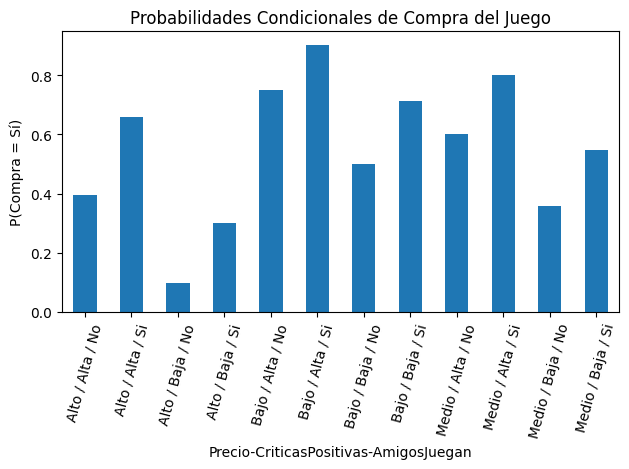

In [10]:
#Combinar precio, criticas_positivas y amigos_juegan en una sola etiqueta en el axis x
prob_compra['Etiqueta'] = prob_compra['Precio'] + ' / ' + prob_compra['Criticas_Positivas'] + ' / ' + prob_compra['Amigos_Juegan']

fig, ax = plt.subplots()

prob_compra.plot(
    kind='bar',
    x='Etiqueta',
    y='Compra',
    ax=ax,
    legend=False
)

ax.set_ylabel('P(Compra = Sí)')
ax.set_title('Probabilidades Condicionales de Compra del Juego')
plt.xlabel('Precio-CriticasPositivas-AmigosJuegan')
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig('probabilidades_condicionales_compra.png')
plt.show()